# 🔍 Análisis Exploratorio — Siniestros de Tránsito Fatales (2021–2025)
Objetivo: entender el dataset, identificar datos sucios, evaluar distribución de clases
y definir qué columnas usar como features y target para la red neuronal.

## 1. Carga y vista general

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('datos.csv', encoding='utf-8', low_memory=False)

print(f"Registros : {len(df):,}")
print(f"Columnas  : {df.shape[1]}")
df.head(3)

Registros : 25,412
Columnas  : 32


,CÓDIGO SINIESTRO,CÓDIGO VEHÍCULO,CÓDIGO PERSONA,DEPARTAMENTO,PROVINCIA,DISTRITO,TIPO PERSONA,GRAVEDAD,LUGAR ATENCIÓN LESIONADO,LUGAR DE DEFUNCIÓN,...,AÑO,MES,DIA,HORA,CLASE DE SINIESTRO,CAUSA,CAUSA ESPECIFICA,TIPO DE VÍA,CÓDIGO DE CARRETERA,RED VIAL
0,A-2021-01-23,V-2021-01-23-1,P-2021-01-23-1-1,LIMA,HUARAL,HUARAL,CONDUCTOR,FALLECIDO,NaN,CAMINO AL CENTRO DE SALUD,...,2021,ENERO,VIERNES,4,DESPISTE,EN PROCESO DE INVESTIGACIÓN,NO CUENTA CON CAUSA ESPECIFICA,CARRETERA PROVINCIAL,LM-671,PROVINCIAL
1,A-2021-01-248,V-2021-01-248-1,P-2021-01-248-1-1,LIMA,LIMA,PACHACAMAC,CONDUCTOR,LESIONADO,CENTRO DE SALUD PÚBLICO,NaN,...,2021,ENERO,VIERNES,5,DESPISTE,IMPRUDENCIA DEL CONDUCTOR,CONDUCIR EN ESTADO DE EBRIEDAD Y/O DROGADICCIÓN,AVENIDA,NO CORRESPONDE,URBANO
2,A-2021-01-248,V-2021-01-248-1,P-2021-01-248-1-2,LIMA,LIMA,PACHACAMAC,PASAJERO,FALLECIDO,NaN,EN EL LUGAR DE LOS HECHOS,...,2021,ENERO,VIERNES,5,DESPISTE,IMPRUDENCIA DEL CONDUCTOR,CONDUCIR EN ESTADO DE EBRIEDAD Y/O DROGADICCIÓN,AVENIDA,NO CORRESPONDE,URBANO


In [2]:
# Tipos y nulos por columna
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'nulos'   : df.isnull().sum(),
    '% nulo'  : (df.isnull().mean() * 100).round(2),
    'únicos'  : df.nunique()
})
info

,dtype,nulos,% nulo,únicos
CÓDIGO SINIESTRO,object,0,0.00,9106
CÓDIGO VEHÍCULO,object,0,0.00,12631
CÓDIGO PERSONA,object,0,0.00,25411
DEPARTAMENTO,object,0,0.00,25
PROVINCIA,object,0,0.00,182
DISTRITO,object,0,0.00,1086
TIPO PERSONA,object,0,0.00,6
GRAVEDAD,object,0,0.00,4
LUGAR ATENCIÓN LESIONADO,object,18341,72.17,3
LUGAR DE DEFUNCIÓN,object,15341,60.37,3


## 2. Análisis de valores nulos

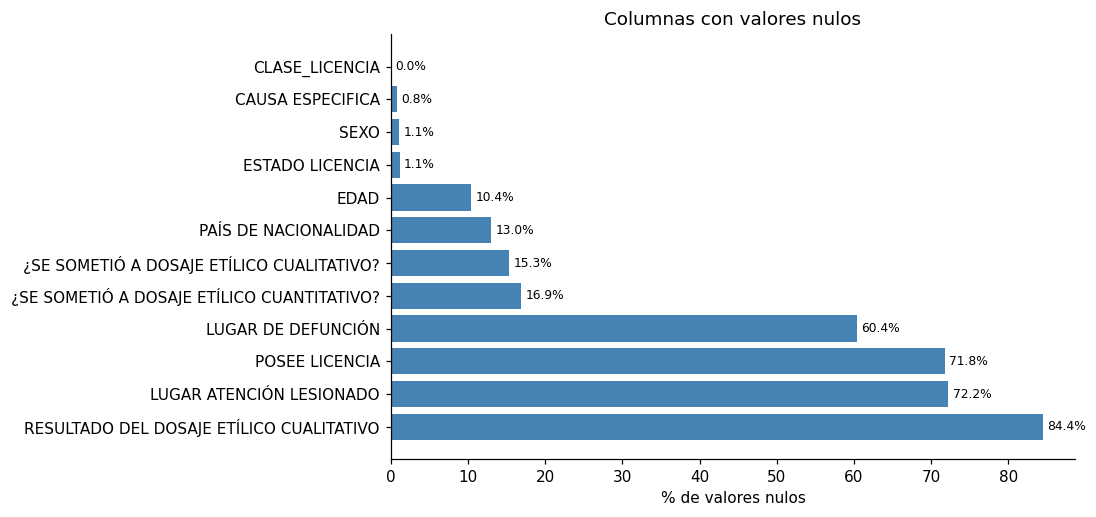


Columnas con >50% nulos (candidatas a eliminar):
RESULTADO DEL DOSAJE ETÍLICO CUALITATIVO    84.436487
LUGAR ATENCIÓN LESIONADO                    72.174563
POSEE LICENCIA                              71.761373
LUGAR DE DEFUNCIÓN                          60.369117


In [3]:
nulos = (df.isnull().mean() * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0]

fig, ax = plt.subplots(figsize=(10, max(3, len(nulos) * 0.4)))
bars = ax.barh(nulos.index, nulos.values, color='steelblue')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xlabel('% de valores nulos')
ax.set_title('Columnas con valores nulos')
plt.tight_layout()
plt.show()

print("\nColumnas con >50% nulos (candidatas a eliminar):")
print(nulos[nulos > 50].to_string())

## 3. Variable target — GRAVEDAD

In [4]:
print("Valores únicos en GRAVEDAD:")
print(df['GRAVEDAD'].value_counts(dropna=False))

Valores únicos en GRAVEDAD:
GRAVEDAD
FALLECIDO       10859
LESIONADO        7830
ILESO            5284
NO SE CONOCE     1439
Name: count, dtype: int64


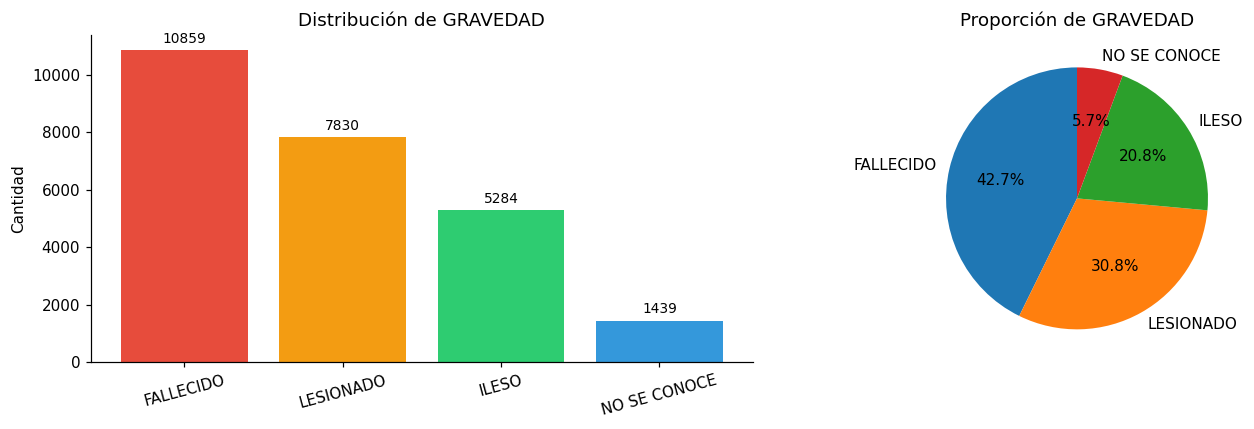


¿Está balanceado? Ratio max/min = 7.5x


In [5]:
gravedad_counts = df['GRAVEDAD'].value_counts(dropna=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras
ax = axes[0]
bars = ax.bar(gravedad_counts.index, gravedad_counts.values,
              color=['#E74C3C','#F39C12','#2ECC71','#3498DB'][:len(gravedad_counts)])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Distribución de GRAVEDAD')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=15)

# Pie
ax2 = axes[1]
ax2.pie(gravedad_counts.values, labels=gravedad_counts.index,
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Proporción de GRAVEDAD')

plt.tight_layout()
plt.show()

print(f"\n¿Está balanceado? Ratio max/min = {gravedad_counts.max()/gravedad_counts.min():.1f}x")

## 4. Variable target alternativa — CLASE DE SINIESTRO

In [6]:
clase_counts = df['CLASE DE SINIESTRO'].value_counts(dropna=False)
print(f"Clases únicas: {len(clase_counts)}")
print(clase_counts.to_string())

Clases únicas: 11
CLASE DE SINIESTRO
CHOQUE                    9814
DESPISTE                  7675
ATROPELLO                 3922
ATROPELLO FUGA            1777
VOLCADURA                  807
CHOQUE FUGA                647
CHOQUE CON OBJETO FIJO     303
CAÍDA DE PASAJERO          220
ESPECIAL                   211
FERROVIARIO                 26
INCENDIO                    10


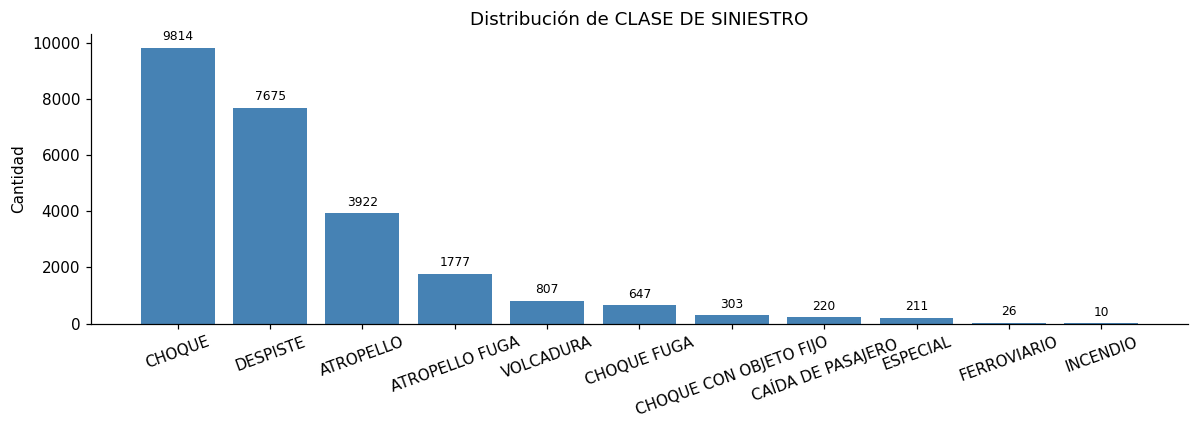


Ratio max/min = 981.4x


In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(clase_counts.index, clase_counts.values, color='steelblue')
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Distribución de CLASE DE SINIESTRO')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print(f"\nRatio max/min = {clase_counts.max()/clase_counts.min():.1f}x")

## 5. Variable target alternativa — CAUSA ESPECÍFICA

In [8]:
causa_counts = df['CAUSA ESPECIFICA'].value_counts(dropna=False)
print(f"Causas únicas: {len(causa_counts)}")
print(causa_counts.head(20).to_string())

Causas únicas: 39
CAUSA ESPECIFICA
NO CUENTA CON CAUSA ESPECIFICA                     12443
EXCESO DE VELOCIDAD                                 3342
OTRO (IMPRUDENCIA DEL CONDUCTOR)                    2400
CONDUCIR EN ESTADO DE EBRIEDAD Y/O DROGADICCIÓN     1470
INVASIÓN DE CARRIL                                  1250
FATIGA Y/O CANSANCIO                                 711
CRUCE INDEBIDO POR LA CALZADA                        562
OTRO (NEGLIGENCIA DEL CONDUCTOR)                     462
ESTADO DE EBRIEDAD Y/O DROGADICCIÓN                  320
GIRAR IMPRUDENTEMENTE                                306
OTRO (IMPRUDENCIA DEL PEATÓN)                        303
ADELANTAR INDEBIDAMENTE                              285
CONDUCIR EN SENTIDO CONTRARIO                        201
NaN                                                  198
CONDUCIR CON FALLAS DE FRENOS                        193
NO ESTABLECER EL DERECHO DE PASO                     168
FACTOR AMBIENTAL                                     

TypeError: 'value' must be an instance of str or bytes, not a float

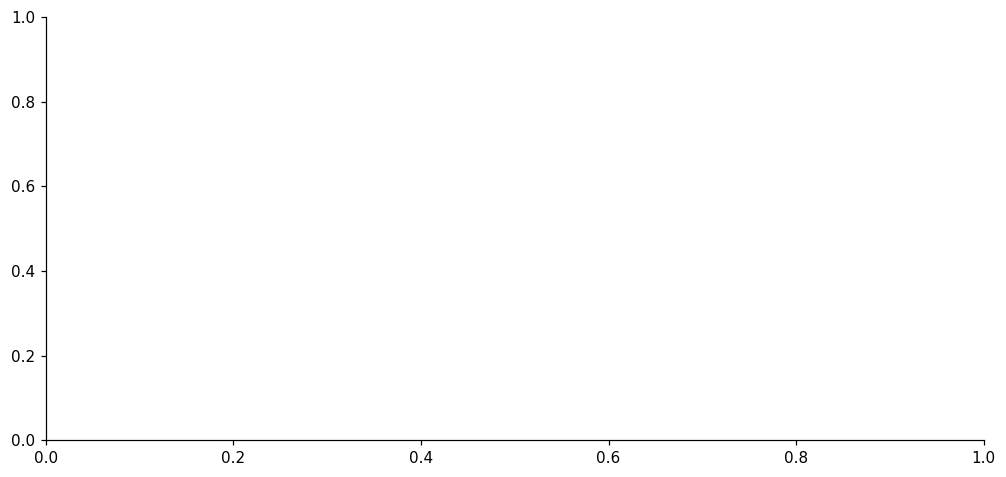

In [9]:
# Top 15 causas
top15 = causa_counts.head(15)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue')
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('Top 15 — CAUSA ESPECÍFICA')
ax.set_xlabel('Cantidad')
plt.tight_layout()
plt.show()

cobertura = top15.sum() / len(df) * 100
print(f"\nTop 15 cubren el {cobertura:.1f}% del dataset")

## 6. Features numéricas — EDAD y HORA

TypeError: '>=' not supported between instances of 'str' and 'int'

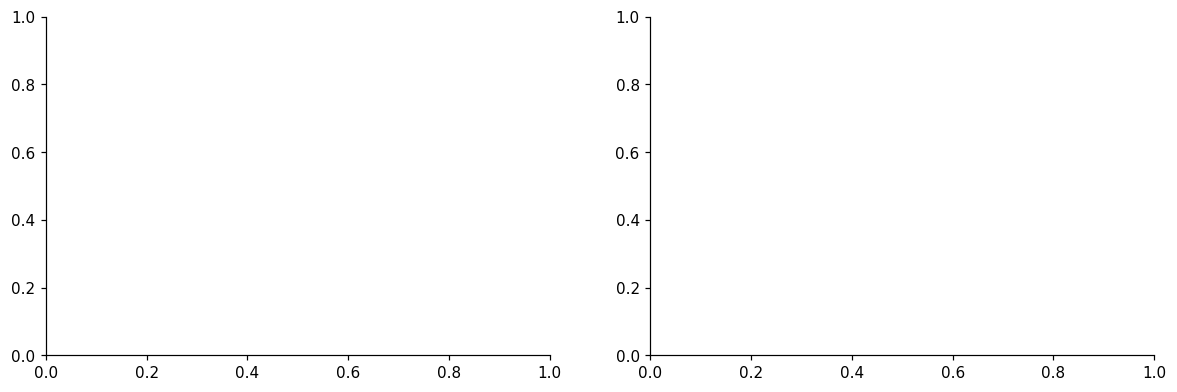

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# EDAD
ax = axes[0]
edad_clean = df['EDAD'].dropna()
edad_clean = edad_clean[(edad_clean >= 0) & (edad_clean <= 120)]
ax.hist(edad_clean, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Distribución EDAD')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
print(f"EDAD — min: {edad_clean.min():.0f}, max: {edad_clean.max():.0f}, "
      f"media: {edad_clean.mean():.1f}, nulos: {df['EDAD'].isnull().sum()}")

# HORA
ax2 = axes[1]
hora_clean = df['HORA'].dropna()
hora_clean = hora_clean[(hora_clean >= 0) & (hora_clean <= 23)]
ax2.hist(hora_clean, bins=24, color='#F0A500', edgecolor='white', linewidth=0.5)
ax2.set_title('Distribución HORA')
ax2.set_xlabel('Hora del día')
ax2.set_ylabel('Frecuencia')
print(f"HORA — min: {hora_clean.min():.0f}, max: {hora_clean.max():.0f}, "
      f"nulos: {df['HORA'].isnull().sum()}")

plt.tight_layout()
plt.show()

In [11]:
# Valores anómalos en EDAD
print("Valores de EDAD fuera de rango [0-120]:")
print(df[~df['EDAD'].between(0, 120)]['EDAD'].value_counts().head(10))

print("\nValores de HORA fuera de rango [0-23]:")
print(df[~df['HORA'].between(0, 23)]['HORA'].value_counts().head(10))

Valores de EDAD fuera de rango [0-120]:


TypeError: '>=' not supported between instances of 'str' and 'int'

## 7. Features categóricas clave

In [12]:
cat_cols = ['DEPARTAMENTO', 'TIPO PERSONA', 'SEXO', 'POSEE LICENCIA',
            'CLASE_LICENCIA', 'VEHÍCULO', 'MES', 'DIA', 'TIPO DE VÍA',
            'RESULTADO DEL DOSAJE ETÍLICO CUALITATIVO']

for col in cat_cols:
    if col in df.columns:
        vc = df[col].value_counts(dropna=False)
        print(f"\n{'─'*50}")
        print(f"{col} ({len(vc)} únicos)")
        print(vc.head(8).to_string())


──────────────────────────────────────────────────
DEPARTAMENTO (25 únicos)
DEPARTAMENTO
LIMA           4728
LA LIBERTAD    2456
CUSCO          2345
AREQUIPA       2296
PUNO           1855
CAJAMARCA      1561
ICA            1245
PIURA          1205

──────────────────────────────────────────────────
TIPO PERSONA (6 únicos)
TIPO PERSONA
CONDUCTOR           11238
PASAJERO             9329
PEATÓN               3104
CONDUCTOR FUGADO     1215
OCUPANTE              403
SIN CONDUCTOR         123

──────────────────────────────────────────────────
SEXO (4 únicos)
SEXO
MASCULINO    18208
FEMENINO      5680
NO INDICA     1236
NaN            288

──────────────────────────────────────────────────
POSEE LICENCIA (3 únicos)
POSEE LICENCIA
NaN    18236
SI      6384
NO       792

──────────────────────────────────────────────────
CLASE_LICENCIA (24 únicos)
CLASE_LICENCIA
NO CONDUCTOR    12975
SIN LICENCIA     2639
A III C          2187
A I              2030
A II B           1429
FUGADO           114

## 8. Cruce CLASE DE SINIESTRO × GRAVEDAD

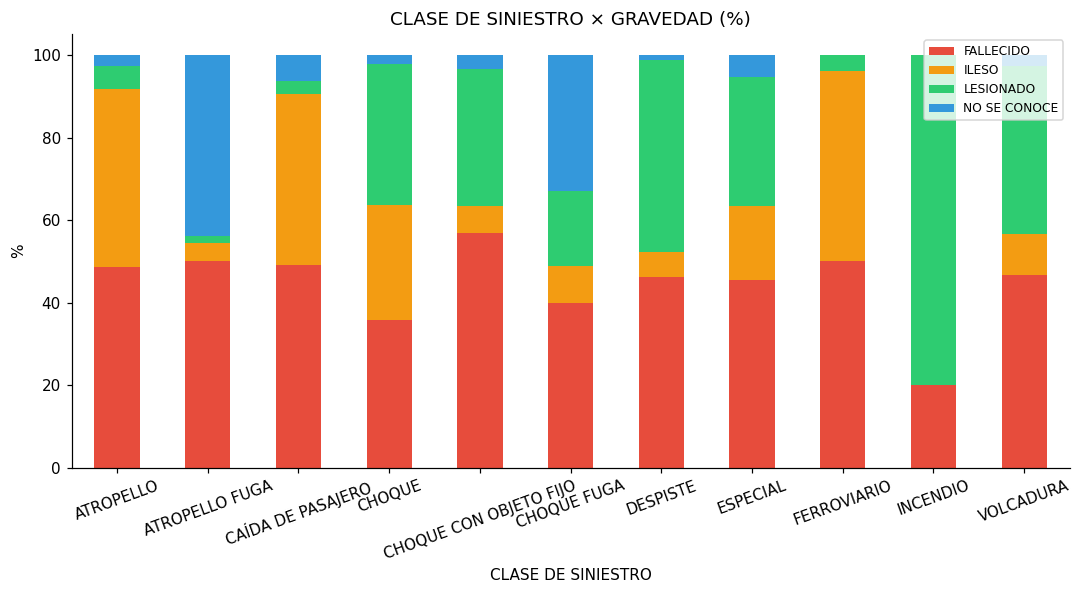

GRAVEDAD                FALLECIDO  ILESO  LESIONADO  NO SE CONOCE
CLASE DE SINIESTRO                                               
ATROPELLO                    48.6   43.1        5.8           2.5
ATROPELLO FUGA               50.1    4.3        1.7          43.9
CAÍDA DE PASAJERO            49.1   41.4        3.2           6.4
CHOQUE                       35.7   28.0       34.2           2.1
CHOQUE CON OBJETO FIJO       56.8    6.6       33.3           3.3
CHOQUE FUGA                  40.0    9.0       18.1          32.9
DESPISTE                     46.1    6.1       46.7           1.1
ESPECIAL                     45.5   18.0       31.3           5.2
FERROVIARIO                  50.0   46.2        3.8           0.0
INCENDIO                     20.0    0.0       80.0           0.0
VOLCADURA                    46.8    9.8       40.8           2.6


In [13]:
cruce = pd.crosstab(df['CLASE DE SINIESTRO'], df['GRAVEDAD'], normalize='index') * 100
cruce = cruce.round(1)

fig, ax = plt.subplots(figsize=(10, max(4, len(cruce) * 0.5)))
cruce.plot(kind='bar', stacked=True, ax=ax,
           color=['#E74C3C','#F39C12','#2ECC71','#3498DB'][:cruce.shape[1]])
ax.set_title('CLASE DE SINIESTRO × GRAVEDAD (%)')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
print(cruce.to_string())

## 9. Identificación de datos sucios

In [14]:
print("=== RESUMEN DE DATOS SUCIOS ===\n")

# 1. Duplicados
dupes = df.duplicated().sum()
print(f"1. Filas duplicadas exactas : {dupes}")

# 2. CAUSA ESPECÍFICA genérica / sin info
sin_causa = df['CAUSA ESPECIFICA'].isin([
    'NO CUENTA CON CAUSA ESPECIFICA',
    'EN PROCESO DE INVESTIGACIÓN',
    'SIN INFORMACIÓN'
]).sum()
print(f"2. CAUSA ESPECÍFICA sin info: {sin_causa} ({sin_causa/len(df)*100:.1f}%)")

# 3. EDAD fuera de rango
edad_raro = df[~df['EDAD'].between(0, 100)].shape[0]
print(f"3. EDAD fuera de [0–100]    : {edad_raro}")

# 4. HORA fuera de rango
hora_raro = df[~df['HORA'].between(0, 23)].shape[0]
print(f"4. HORA fuera de [0–23]     : {hora_raro}")

# 5. SEXO valores raros
sexo_raro = df[~df['SEXO'].isin(['MASCULINO','FEMENINO'])]['SEXO'].value_counts()
print(f"5. SEXO valores no estándar : {sexo_raro.sum()}")
if len(sexo_raro): print(sexo_raro.to_string())

# 6. GRAVEDAD nulos o raros
grav_nulo = df['GRAVEDAD'].isnull().sum()
print(f"6. GRAVEDAD nulos           : {grav_nulo}")

# 7. TIPO PERSONA
print(f"\n7. TIPO PERSONA únicos:")
print(df['TIPO PERSONA'].value_counts(dropna=False).to_string())

=== RESUMEN DE DATOS SUCIOS ===

1. Filas duplicadas exactas : 0
2. CAUSA ESPECÍFICA sin info: 12443 (49.0%)


TypeError: '>=' not supported between instances of 'str' and 'int'

## 10. Propuesta de limpieza y selección de features

In [15]:
print("""
PROPUESTA DE LIMPIEZA
=====================

ELIMINAR columnas:
  - CÓDIGO SINIESTRO / CÓDIGO VEHÍCULO / CÓDIGO PERSONA  → IDs, no aportan
  - LUGAR ATENCIÓN LESIONADO / LUGAR DE DEFUNCIÓN         → >50% nulos o post-evento
  - SITUACIÓN DE PERSONA                                  → redundante con GRAVEDAD
  - PAÍS DE NACIONALIDAD                                  → casi uniforme (Perú)
  - POSEE LICENCIA / ESTADO LICENCIA                      → alta correlación entre sí
  - RESULTADO DOSAJE CUANTITATIVO                         → >80% nulos
  - CÓDIGO DE CARRETERA                                   → demasiados valores únicos
  - CAUSA / CAUSA ESPECIFICA                              → si son el target, no van como feature
  - AÑO / FECHA                                           → AÑO puede quedarse como feature

FILTRAR filas:
  - EDAD fuera de [0, 100]
  - HORA fuera de [0, 23]
  - GRAVEDAD nulos
  - CAUSA ESPECÍFICA = 'NO CUENTA CON CAUSA ESPECIFICA' (si es el target)

FEATURES finales propuestas:
  Numéricas  : EDAD, HORA, AÑO
  Categóricas: DEPARTAMENTO, TIPO PERSONA, SEXO, CLASE_LICENCIA,
               DOSAJE ETÍLICO CUALITATIVO, VEHÍCULO, MES, DIA,
               TIPO DE VÍA, RED VIAL

TARGET opciones:
  A) GRAVEDAD          → 3-4 clases (FALLECIDO / HERIDO / ILESO)
  B) CLASE DE SINIESTRO → menos clases, mejor balanceado
""")


PROPUESTA DE LIMPIEZA

ELIMINAR columnas:
  - CÓDIGO SINIESTRO / CÓDIGO VEHÍCULO / CÓDIGO PERSONA  → IDs, no aportan
  - LUGAR ATENCIÓN LESIONADO / LUGAR DE DEFUNCIÓN         → >50% nulos o post-evento
  - SITUACIÓN DE PERSONA                                  → redundante con GRAVEDAD
  - PAÍS DE NACIONALIDAD                                  → casi uniforme (Perú)
  - POSEE LICENCIA / ESTADO LICENCIA                      → alta correlación entre sí
  - RESULTADO DOSAJE CUANTITATIVO                         → >80% nulos
  - CÓDIGO DE CARRETERA                                   → demasiados valores únicos
  - CAUSA / CAUSA ESPECIFICA                              → si son el target, no van como feature
  - AÑO / FECHA                                           → AÑO puede quedarse como feature

FILTRAR filas:
  - EDAD fuera de [0, 100]
  - HORA fuera de [0, 23]
  - GRAVEDAD nulos
  - CAUSA ESPECÍFICA = 'NO CUENTA CON CAUSA ESPECIFICA' (si es el target)

FEATURES finales propuestas:
  Numér

## 11. Limpieza aplicada y dataset final

In [ ]:
df_clean = df.copy()

# ── Eliminar columnas innecesarias ────────────────────────────────────────────
drop_cols = [
    'CÓDIGO SINIESTRO', 'CÓDIGO VEHÍCULO', 'CÓDIGO PERSONA',
    'LUGAR ATENCIÓN LESIONADO', 'LUGAR DE DEFUNCIÓN',
    'SITUACIÓN DE PERSONA', 'PAÍS DE NACIONALIDAD',
    'POSEE LICENCIA', 'ESTADO LICENCIA',
    'RESULTADO DEL DOSAJE ETÍLICO CUANTITATIVO',
    'CÓDIGO DE CARRETERA', 'FECHA', 'CAUSA', 'CAUSA ESPECIFICA'
]
drop_cols = [c for c in drop_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

# ── Filtrar filas sucias ──────────────────────────────────────────────────────
antes = len(df_clean)
df_clean = df_clean[df_clean['EDAD'].between(0, 100)]
df_clean = df_clean[df_clean['HORA'].between(0, 23)]
df_clean = df_clean[df_clean['GRAVEDAD'].notna()]
df_clean = df_clean[df_clean['CLASE DE SINIESTRO'].notna()]
df_clean = df_clean[df_clean['SEXO'].isin(['MASCULINO','FEMENINO'])]
df_clean = df_clean.drop_duplicates()
despues = len(df_clean)

print(f"Filas antes : {antes:,}")
print(f"Filas después: {despues:,}  (eliminadas: {antes-despues:,})")
print(f"\nColumnas restantes ({df_clean.shape[1]}):")
print(list(df_clean.columns))

In [ ]:
# ── Distribución del target final ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['GRAVEDAD', 'CLASE DE SINIESTRO']):
    vc = df_clean[col].value_counts()
    bars = ax.bar(vc.index, vc.values, color='steelblue')
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_title(f'Target: {col} (limpio)')
    ax.tick_params(axis='x', rotation=20)
    ratio = vc.max() / vc.min()
    ax.set_xlabel(f'Ratio desbalance: {ratio:.1f}x')

plt.tight_layout()
plt.show()

In [ ]:
# ── Nulos restantes ───────────────────────────────────────────────────────────
nulos_restantes = df_clean.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0].sort_values(ascending=False)
print("Nulos restantes:")
print(nulos_restantes.to_string() if len(nulos_restantes) else "Ninguno ✓")

# ── Guardar dataset limpio ────────────────────────────────────────────────────
df_clean.to_csv('datos_limpios.csv', index=False, encoding='utf-8')
print(f"\n✓ Guardado como 'datos_limpios.csv' — {len(df_clean):,} registros, {df_clean.shape[1]} columnas")

## 12. Conclusiones del EDA

A completar luego de correr el notebook con tus datos reales. Estructura sugerida:

**Calidad del dataset**
- X% de filas eliminadas por datos sucios
- Columnas con demasiados nulos eliminadas: ...

**Target elegido**
- Se usará `CLASE DE SINIESTRO` / `GRAVEDAD` porque ...
- Distribución de clases: ... (ratio desbalance: Xx)
- Estrategia de balanceo: class weights / undersampling / ...

**Features seleccionadas**
- Numéricas: EDAD, HORA, AÑO
- Categóricas (one-hot): DEPARTAMENTO, TIPO PERSONA, SEXO, ...
- Total de features estimadas tras one-hot: ~N
